In [1]:
import os, sys
sys.path.append('../neural_model_identification')
os.getcwd()

'/home/dema/Project/simple_neural_mpc/dev_notebook'

In [42]:
from Agent.AbstractLearner import AbstractLearner
from Agent.PINN_uniKin_Learner import PINNLearner
from Agent.neural_nets.MLP import MLP
from Agent.neural_nets.RNN import RNN

from Agent.dyn_utils.utils import (
    euler_integration,
    normalize_state,
    denormalize_state
)
from parameters.train_params import TrainParams
from data_module.preprocess import DataPreProcess

import numpy as np
import torch 
from torch.func import jacrev
from torch.func import vmap

from typing import Tuple
import matplotlib.pyplot as plt

In [43]:
path = "../neural_model_identification/data_module/PINN/"
actions = np.load(path + "sample_0/actions.npy")
states = np.load(path + "sample_0/states.npy")

states.shape, actions.shape

((1001, 3), (1000, 2))

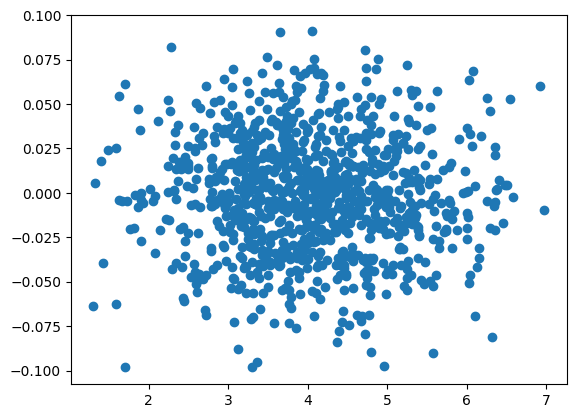

In [41]:
#plt.scatter(states[:, 0], states[:, 1])
plt.scatter(actions[:, 0], actions[:, 1])

In [44]:
states.max(0)

array([1.17823728e+03, 2.09499441e+02, 4.19413730e-01])

In [34]:
states = normalize_state(states, x_max=states.max(0), x_min=states.min(0))
actions = normalize_state(actions, x_max=actions.max(0), x_min=actions.min(0))

In [13]:
params = TrainParams()

In [14]:
# X-0 [state(0)_i, action_const, t=0] (init state, time 0, const input ) --> Y0 = [init state]   
# X-1 [state(0)_i, action_const, t=T] (init state, time T, const input ) --> Y1 = [next state]

X, Y = [], []


delta_t = 0.3
for i in range(states.shape[0] - 1):
    x0 = np.hstack((0, states[i, :], actions[i]))
    y0 = states[i, :]

    x1 = np.hstack((0.3, states[i, :], actions[i]))
    y1 = states[i+1, :]

    X.append(torch.FloatTensor(x0))
    X.append(torch.FloatTensor(x1))
    Y.append(torch.FloatTensor(y0))
    Y.append(torch.FloatTensor(y1))



dataset_tensor = torch.hstack((torch.vstack(X), torch.vstack(Y)))

In [15]:
dataset_tensor[10, :-3]

tensor([ 0.0000, -0.9881, -0.9847,  0.2941,  0.2075, -0.4270])

In [16]:
states_range = (states.max(0), states.min(0))
actions_range = (actions.max(0), actions.min(0))


In [1016]:
actions_range

(array([1., 1.]), array([-1., -1.]))

In [ ]:
actt = [-0.6 === 1.5] ---> [-1. 1]
state = [0.0 --- 500] --> [-1, 1]



xdot = v cos(theta) 

In [27]:
class PINNLearnerDEMA(AbstractLearner):

    def __init__(self,
                 data_tensor: torch.Tensor,
                 max_min_states: Tuple, 
                 max_min_actions: Tuple, 
                 delta_t = 0.3,
                 device='cpu'):
        super(AbstractLearner, self).__init__()
        
        self.device = device
        self.demos = data_tensor.to(self.device)
        self.batch_size = 512

        self.state_dim = 3
        self.action_dim = 2

        self.states_max= torch.FloatTensor(max_min_states[0]).to(self.device)
        self.states_min = torch.FloatTensor(max_min_states[1]).to(self.device)

        self.actions_max = torch.FloatTensor(max_min_actions[0]).to(self.device)
        self.actions_min = torch.FloatTensor(max_min_actions[1]).to(self.device)

        self.delta_t = delta_t

        self.n_demos = len(data_tensor)
        self.input_dim = self.state_dim + self.action_dim + 1

        self.model = MLP(
            state_dim=self.state_dim,
            input_dim=self.action_dim,
            n_hidden_layer=1, 
            latent_dim=32, 
            time=True,
        ).to(self.device)

        self.imit_weight = 1
        self.physic_weight = 1
        self.boundary_weight = 1

        self.mse_loss = torch.nn.MSELoss()
        
        
         
        self.optimizer = torch.optim.Adam(
            self.model.parameters(),
            lr=0.00001,
            weight_decay=0.000001,
            )
        
        '''
        self.optimizer = torch.optim.LBFGS(
            self.model.parameters(),
            lr=0.7,
            history_size=10,
            max_iter=4,
            line_search_fn='strong_wolfe',
            )
        '''
        
    
    def normalize(self, x, x_min, x_max):
        return (x_max - x_min) *x + x_min
        

    def calc_loss(self, sample):

        tot_loss = 0
        stats = {}
        # 1) imit loss --> this encapsulate the boundary condition
        if self.imit_weight != 0:
            
            X_imit, y_imit = sample[:, :self.input_dim], sample[:, self.input_dim:]
            y_hat = self.model(X_imit)

            imit_loss = self.mse_loss(y_imit, y_hat) * self.imit_weight
            tot_loss += imit_loss
            stats['imit'] = imit_loss.item()

        # sampling are down here
        sample_batch_size = 1028

        # 2) physics loss --> use derivative respect time  
        if self.physic_weight != 0:
            
            # element for the loss allocation
            grad_stock = torch.zeros((sample_batch_size, self.state_dim), device=self.device)
            f = torch.zeros((sample_batch_size, self.state_dim), device=self.device) 

            # sample state, action, time
            state = torch.randn(sample_batch_size, self.state_dim, device=self.device)
            action = torch.randn(sample_batch_size, self.action_dim, device=self.device)
            t = torch.rand(sample_batch_size, 1, device=self.device)

            # normalize in the training range
            # actual range is -1, 1 but let see if some scaling can help
            state = self.normalize(state, -0.5, 0.5)
            # state = self.normalize(state, self.states_min, self.states_max) 
            action = self.normalize(action, self.actions_min, self.actions_max)
            t = self.normalize(t, 0, self.delta_t)

            # create input vect
            X_physic = torch.hstack((state, action, t))
            X_physic.requires_grad = True

            # calc derivative --> vmap is used to vectorize the jacobian calculation
            #                 --> jacrev is used to calculate the jacobian of the model
            jac = vmap(jacrev(self.model))(X_physic)

            # jac is a 3x6, last column is the derivative respect time
            grad_stock = jac[:, :, -1]

            # physic model
            f[:, 0] = torch.cos(X_physic[:, 2])*X_physic[:, 3]
            f[:, 1] = torch.sin(X_physic[:, 2])*X_physic[:, 3]
            f[:, 2] = X_physic[:, 4]

            # calc cost 
            cost = ((grad_stock - f)**2).mean() * self.physic_weight
            
            # add logs
            tot_loss +=  cost
            stats['physic'] = cost.item()
        

        # boundary loss : 
        if self.boundary_weight != 0:
            # our boundary condition : any times that the velocity is zero, the state must stay at rest

            # sample state, time. Action is zero
            state = torch.randn(sample_batch_size, self.state_dim, device=self.device)
            action = torch.zeros(sample_batch_size, self.action_dim, device=self.device)
            t = torch.rand(sample_batch_size, 1, device=self.device)
            
            # actual range is -1, 1 but let see if some scaling can help
            state = self.normalize(state, 0, 1) 
            # state = self.normalize(state, self.states_min, self.states_max) 
            # action must be zero
            t = self.normalize(t, 0, self.delta_t)

            # target of the model for this: the same as the input
            Y_BC = state.clone()

            X_BC = torch.hstack((state, action, t))
            X_BC.requires_grad = True

            # calc the prediction
            y_hat_BC = self.model(X_BC)

            # mse loss
            BC_loss = self.mse_loss(y_hat_BC, Y_BC) * self.boundary_weight

            # add logs
            tot_loss += BC_loss
            stats['BC'] = BC_loss.item()



        stats['tot'] = tot_loss.item()

        return tot_loss, stats
    
    def train_step(self):
        # adam
        # ------------
        sample = self.sample_data() 
        loss, stats = self.calc_loss(sample)
        self.update_model(loss)
        return loss, stats

        # lsbf
        # ------------
        #loss = self.update_model(None)
        #return loss

    def sample_data(self):

        #batch = self.demos[
        #    torch.randint(
        #        low=0, 
        #        high=self.n_demos, 
        #        #size=(self.batch_size, )
        #        size=(len(self.demos), )
        #    )
        #]
        idx = torch.randperm(self.demos.shape[0])
        return self.demos[idx]
    
    def closure(self):
        self.optimizer.zero_grad()
        loss = self.calc_loss(self.sample_data())[0]
        loss.backward()
        return loss


    def update_model(self, loss):
        # adam: 
        # -----------
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        # lsdbf --> comment the all the rest
        #loss = self.optimizer.step(self.closure)
        #return loss
        
    def propagate(self, input_tensor):
        # no euler integration in this learner 
        x_next = self.model(input_tensor)
        return x_next


In [28]:
learner = PINNLearnerDEMA(dataset_tensor,
                          states_range,
                          actions_range,
                          delta_t=0.3,
                          device='cuda')
learner.physic_weight = 1
learner.boundary_weight = 1
learner.imit_weight = 1

j = 0

In [32]:
# tot 6k
for i in range(1000):
    j += 1
    loss, stats = learner.train_step()
    #loss = learner.train_step()
    s = ""
    if (i%10 == 0):
        for item, k in stats.items():
            s += f"{item}: {k} ; "
        print(f"iter: {j} : {s}")            
        #print(f"iter: {i}, loss: {loss.item()}")

iter: 1001 : imit: 0.3639566898345947 ; physic: 2.9144906997680664 ; BC: 0.8102607727050781 ; tot: 4.08870792388916 ; 
iter: 1011 : imit: 0.3633996546268463 ; physic: 3.1029608249664307 ; BC: 0.829246997833252 ; tot: 4.295607566833496 ; 
iter: 1021 : imit: 0.3628406226634979 ; physic: 3.1890759468078613 ; BC: 0.8076056241989136 ; tot: 4.359522342681885 ; 
iter: 1031 : imit: 0.36229410767555237 ; physic: 3.099091053009033 ; BC: 0.7762907147407532 ; tot: 4.23767614364624 ; 
iter: 1041 : imit: 0.3617386817932129 ; physic: 3.2025952339172363 ; BC: 0.7973206639289856 ; tot: 4.361654758453369 ; 
iter: 1051 : imit: 0.36119043827056885 ; physic: 3.2453904151916504 ; BC: 0.8295114636421204 ; tot: 4.436092376708984 ; 
iter: 1061 : imit: 0.36065196990966797 ; physic: 3.0710301399230957 ; BC: 0.7619912028312683 ; tot: 4.193673133850098 ; 
iter: 1071 : imit: 0.3601136803627014 ; physic: 3.1427199840545654 ; BC: 0.7755592465400696 ; tot: 4.278392791748047 ; 
iter: 1081 : imit: 0.3595794141292572 ; p

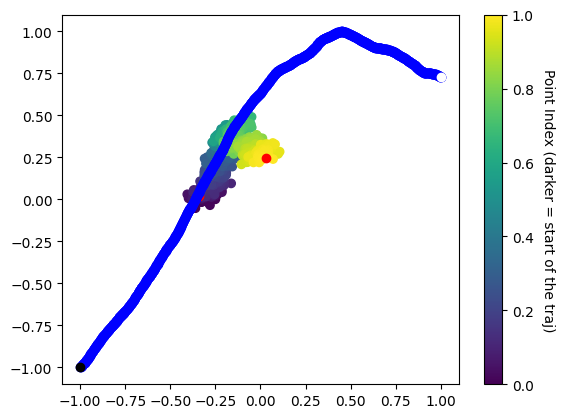

In [33]:

x_0 = torch.FloatTensor(states[0, :]).to('cuda')
a_0 = torch.FloatTensor(actions[0, :]).to('cuda')
t = torch.FloatTensor([0.3]).to('cuda')
pair = torch.hstack((x_0, a_0, t)).unsqueeze(0)
#pair = torch.hstack((x_0, a_0)).unsqueeze(0)
zero = torch.FloatTensor([0]).to('cuda')

traj_generated = []
for i in range(len(actions)):
    with torch.no_grad():
        
        x_i = learner.model(pair).squeeze()
        pair = torch.hstack((
            #x_i,
            torch.FloatTensor(states[i, :]).to('cuda'), 
            torch.FloatTensor(actions[i, :]).to('cuda'),
            t
        )).unsqueeze(0).to('cuda')
        traj_generated.append(x_i.detach().cpu().numpy())


traj = np.array(traj_generated)

color_id = np.linspace(0, 1, len(traj))
cmap = plt.get_cmap('viridis')
colors = cmap(color_id)

scatter = plt.scatter(traj[:, 0], traj[:, 1], color=colors)
plt.scatter(traj[0, 0], traj[0, 1], color='red')
plt.scatter(traj[-1, 0], traj[-1, 1], color='red')

cbar = plt.colorbar(scatter)
cbar.set_label("Point Index (darker = start of the traj)", rotation=270, labelpad=15)


plt.scatter(states[:, 0], states[:, 1], color='blue')
plt.scatter(states[0, 0], states[0, 1], color='black')
plt.scatter(states[-1, 0], states[-1, 1], color='white')



In [880]:
actions[0

array([ 0.58113557, -0.02186676])

In [700]:
colors

array([[0.267004, 0.004874, 0.329415, 1.      ],
       [0.267004, 0.004874, 0.329415, 1.      ],
       [0.267004, 0.004874, 0.329415, 1.      ],
       ...,
       [0.993248, 0.906157, 0.143936, 1.      ],
       [0.993248, 0.906157, 0.143936, 1.      ],
       [0.993248, 0.906157, 0.143936, 1.      ]])